In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CARGAMOS EL DATASET

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
base_dir = '/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets'

In [4]:
train_dir = os.path.join(base_dir,'train')
validation_dir = os.path.join(base_dir,'validation')
test_dir = os.path.join(base_dir,'test')

In [5]:
train_gatos_dir = os.path.join(train_dir,'gatos')
train_perros_dir = os.path.join(train_dir,'perros')

validation_gatos_dir = os.path.join(validation_dir,'gatos')
validation_perros_dir = os.path.join(validation_dir,'perros')

test_gatos_dir = os.path.join(test_dir,'gatos')
test_perros_dir = os.path.join(test_dir,'perros')

# MOSTRAMOS IMAGEN DE PRUEBA DE NUESTRO DATASET

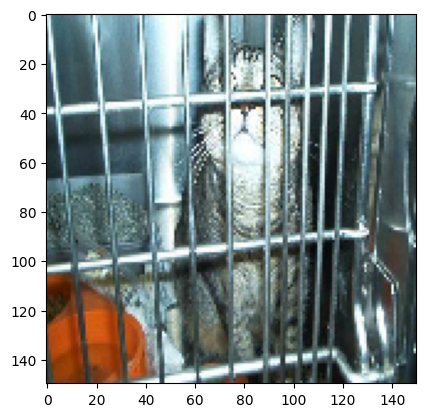

In [6]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

fnames = [os.path.join(train_gatos_dir,fname) for fname in os.listdir(train_gatos_dir)]

img_path = fnames[900]
img = image.load_img(img_path, target_size=(150,150))
x = image.img_to_array(img)

plt.figure()
imgplot = plt.imshow(image.array_to_img(x))
plt.show()

# CREAMOS RED NEURONAL CONVOLUCIONAL CON PYTORCH

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

## CREAR DATASETS DE ENTRENAMIENTO VALIDACIÓN Y PRUEBAS CON ESCALAMIENTO

In [8]:
# Transformaciones para normalizar los datos y ajustar el tamaño de las imágenes
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Cargar los conjuntos de datos
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


val_dataset = datasets.ImageFolder(validation_dir, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

test_dataset = datasets.ImageFolder(test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# CREAMOS NUESTRA RED NEURONAL

In [9]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=(3, 3), stride=(2, 2), padding=1)  # 3 canales de color (RGB), 32 filtros, tamaño de filtro 3x3
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3, 3), padding=1)
        self.fc1 = nn.Linear(64*14*14, 128)  # Ajuste del tamaño después de las capas convolucionales
        self.fc2 = nn.Linear(128, 2)  # Dos clases: perros y gatos

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)  # Aplana para la capa completamente conectada
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## INTANCIAMOS EL MODELO CON USO DE GPU

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)

## CONFIGURAMOS EL MODELO

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## ENTRENAMOS NUESTRO MODELO

In [ ]:
def train(model, train_loader, criterion, optimizer, epochs=10):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
             # Calcular el accuracy
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()


        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100 * correct / total
        print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

# GUARDAMOS EL MODELO

In [ ]:
# Guardar el modelo
model_path = 'dogs_vs_cats_cnn.pth'  # Cambia el nombre y la ruta según sea necesario
torch.save(model.state_dict(), model_path)
print(f"Modelo guardado en {model_path}")